# ❤️ Task 4: Disease Prediction from Medical Data
### CodeAlpha ML Internship  
**Author:** Prajwal Mesare &nbsp;|&nbsp; **GitHub:** [PrajwalMesare](https://github.com/PrajwalMesare) &nbsp;|&nbsp; **LinkedIn:** [prajwal-mesare](https://linkedin.com/in/prajwal-mesare-700678263)

---

## 📌 Objective
Predict the presence of **heart disease** based on clinical patient data.

## 📊 Dataset — Kaggle: *Heart Disease UCI*
| Field | Detail |
|-------|--------|
| Source | UCI ML Repository / Kaggle |
| Rows | 1,025 patients |
| Features | 13 clinical features (age, cholesterol, ECG, etc.) |
| Target | `target` — 1 = Heart Disease, 0 = No Disease |

## 🔄 Pipeline
```
Load Data → EDA → Preprocessing → Model Training (5 models) → Evaluation → Export
```


## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, accuracy_score, precision_score, recall_score
)
import xgboost as xgb

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
os.makedirs('models',  exist_ok=True)
plt.rcParams.update({'figure.dpi': 130})
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Libraries loaded')

✅ Libraries loaded


## 2️⃣ Load Dataset
> 📁 `data/heart.csv` — Kaggle *Heart Disease UCI*

In [2]:
df = pd.read_csv('data/heart.csv')
print(f'Shape  : {df.shape}')
print(f'\nFeature descriptions:')
feature_desc = {
    'age':'Age in years', 'sex':'Sex (1=male, 0=female)',
    'cp':'Chest pain type (0-3)', 'trestbps':'Resting blood pressure',
    'chol':'Serum cholesterol (mg/dl)', 'fbs':'Fasting blood sugar > 120',
    'restecg':'Resting ECG results', 'thalach':'Max heart rate achieved',
    'exang':'Exercise induced angina', 'oldpeak':'ST depression',
    'slope':'Slope of peak exercise ST', 'ca':'Major vessels (0-4)',
    'thal':'Thalassemia type', 'target':'Heart disease (1=Yes)'
}
for k, v in feature_desc.items():
    print(f'  {k:<12}: {v}')
print(f'\nClass distribution:')
print(df['target'].value_counts())
df.head()

Shape  : (1025, 14)

Feature descriptions:
  age         : Age in years
  sex         : Sex (1=male, 0=female)
  cp          : Chest pain type (0-3)
  trestbps    : Resting blood pressure
  chol        : Serum cholesterol (mg/dl)
  fbs         : Fasting blood sugar > 120
  restecg     : Resting ECG results
  thalach     : Max heart rate achieved
  exang       : Exercise induced angina
  oldpeak     : ST depression
  slope       : Slope of peak exercise ST
  ca          : Major vessels (0-4)
  thal        : Thalassemia type
  target      : Heart disease (1=Yes)

Class distribution:
target
0    613
1    412
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,66,1,0,120,166,0,1,136,1,1.6,1,0,1,0
1,38,1,1,137,205,0,2,136,0,2.8,2,1,1,0
2,56,0,0,129,245,0,0,178,0,0.8,0,4,1,1
3,38,1,0,131,281,0,2,155,0,1.2,1,1,1,0
4,56,0,1,143,179,0,0,154,0,0.5,1,2,1,0


## 3️⃣ Exploratory Data Analysis

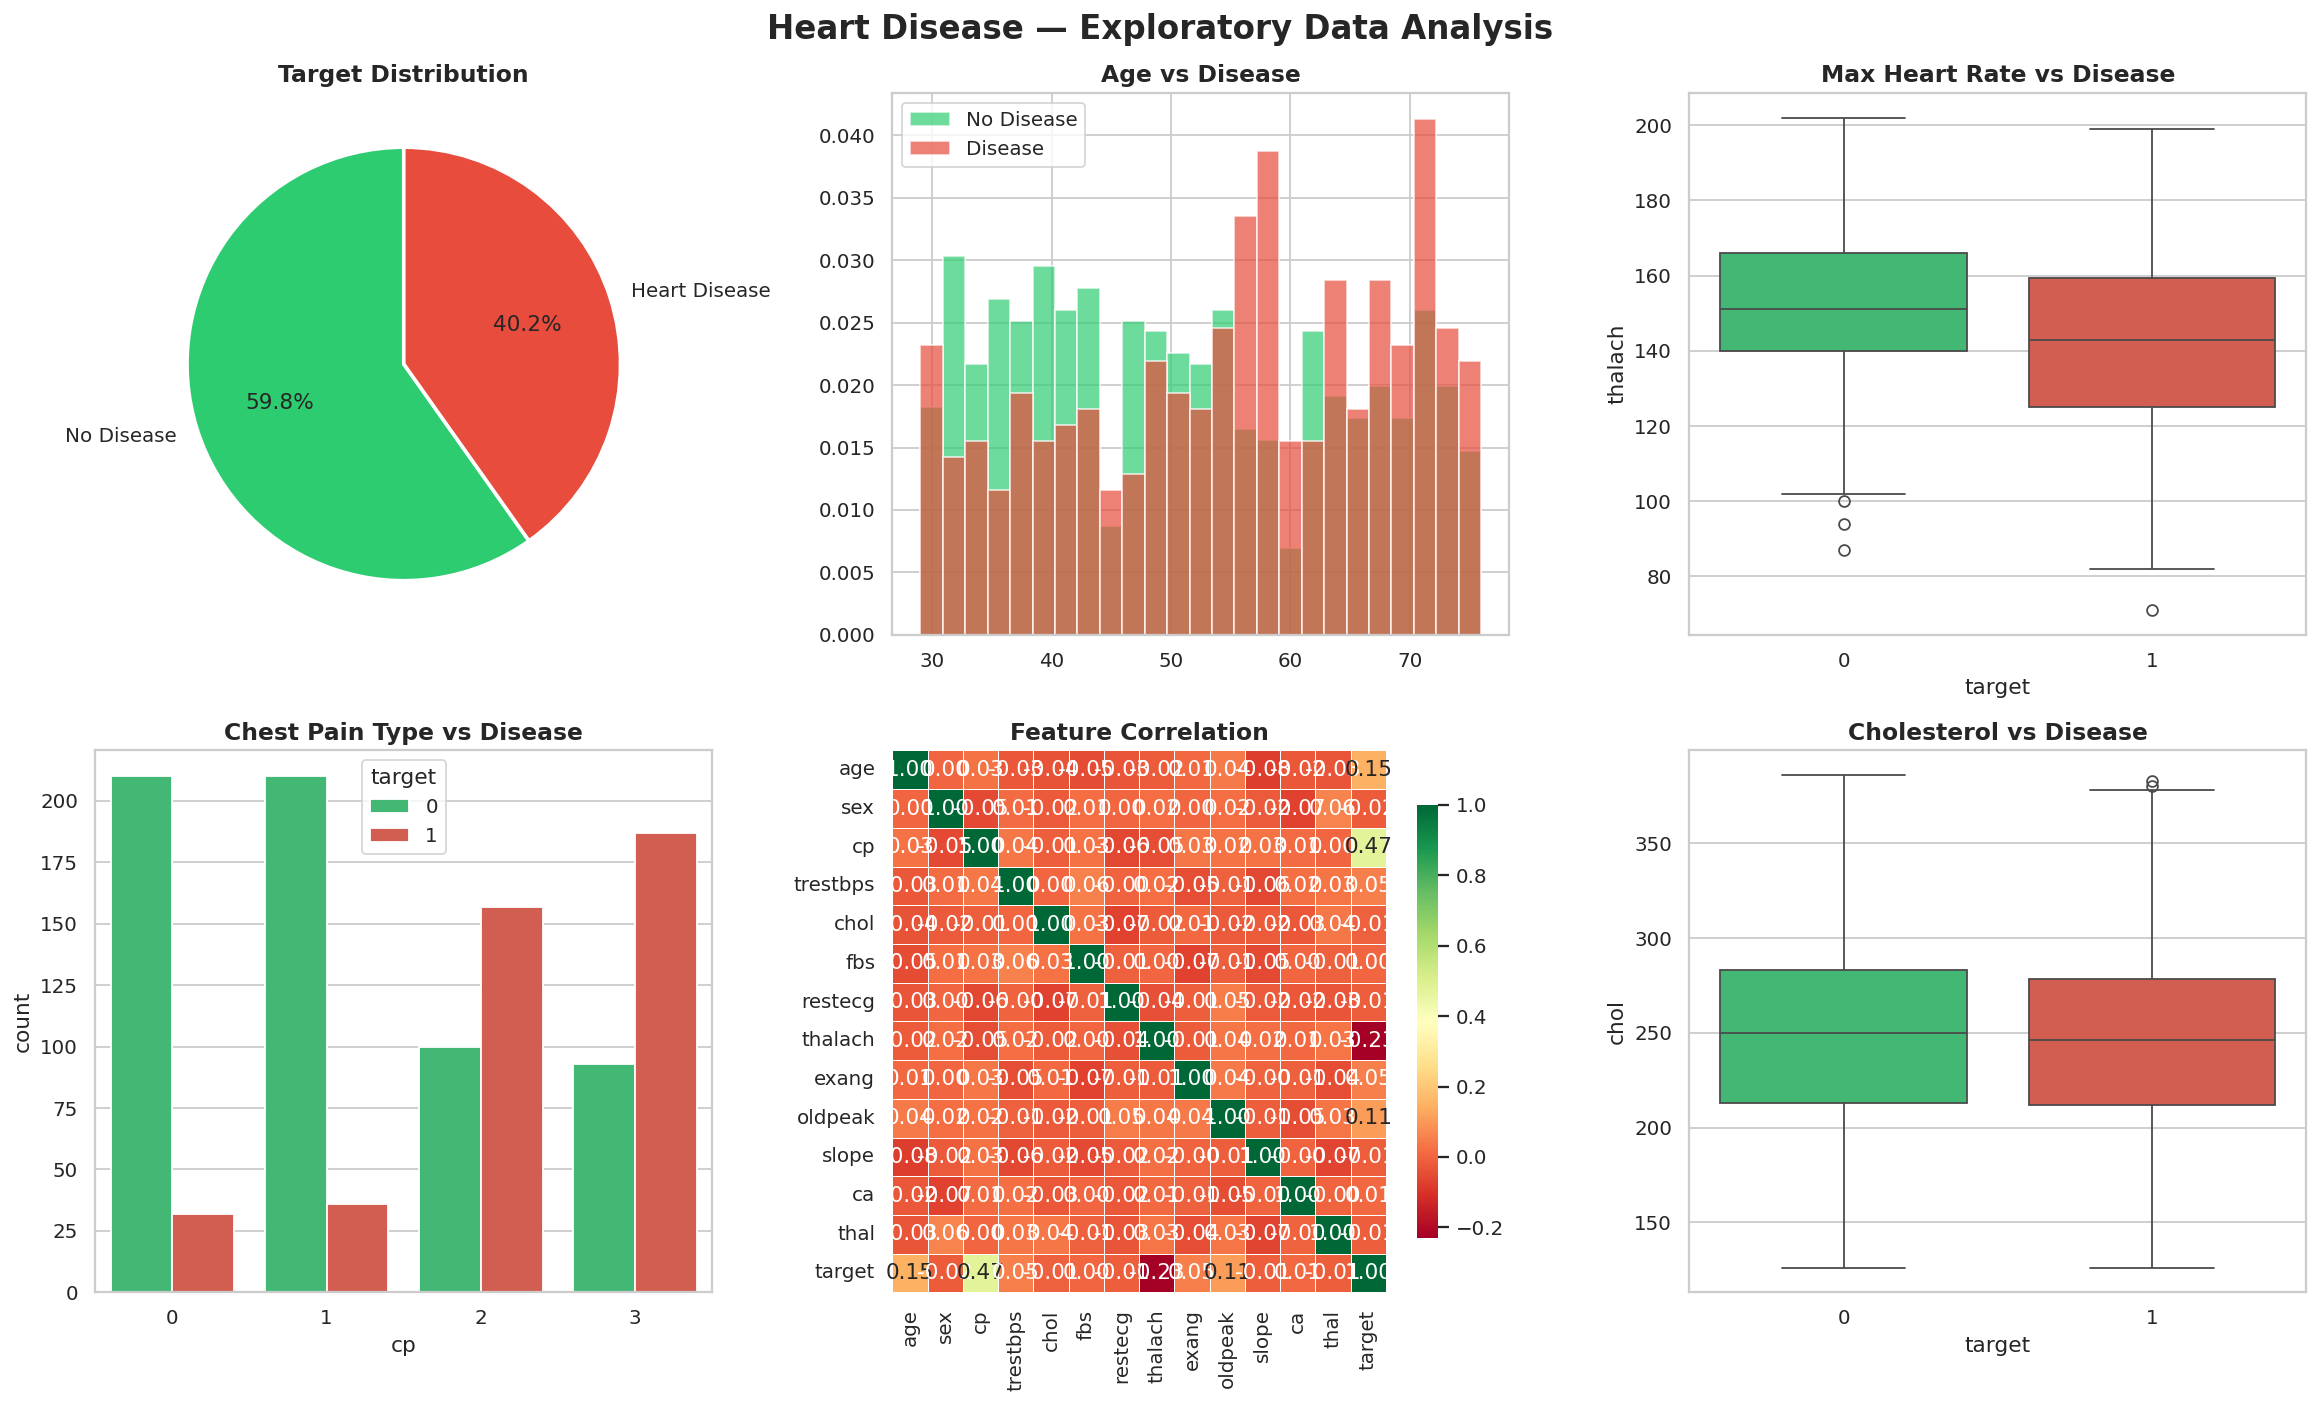

EDA saved → outputs/eda_plots.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Heart Disease — Exploratory Data Analysis', fontsize=18, fontweight='bold')

# 1. Target pie
counts = df['target'].value_counts()
axes[0,0].pie(counts, labels=['No Disease','Heart Disease'], autopct='%1.1f%%',
              colors=['#2ecc71','#e74c3c'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Target Distribution', fontsize=13, fontweight='bold')

# 2. Age by target
df[df['target']==0]['age'].hist(bins=25, ax=axes[0,1], alpha=0.7, color='#2ecc71', label='No Disease', density=True)
df[df['target']==1]['age'].hist(bins=25, ax=axes[0,1], alpha=0.7, color='#e74c3c', label='Disease',    density=True)
axes[0,1].set_title('Age vs Disease', fontsize=13, fontweight='bold'); axes[0,1].legend()

# 3. Max heart rate
sns.boxplot(x='target', y='thalach', data=df, ax=axes[0,2], palette=['#2ecc71','#e74c3c'])
axes[0,2].set_title('Max Heart Rate vs Disease', fontsize=13, fontweight='bold')

# 4. Chest pain type
sns.countplot(x='cp', hue='target', data=df, ax=axes[1,0], palette=['#2ecc71','#e74c3c'])
axes[1,0].set_title('Chest Pain Type vs Disease', fontsize=13, fontweight='bold')

# 5. Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1,1], linewidths=0.3, cbar_kws={'shrink':0.8})
axes[1,1].set_title('Feature Correlation', fontsize=13, fontweight='bold')

# 6. Cholesterol
sns.boxplot(x='target', y='chol', data=df, ax=axes[1,2], palette=['#2ecc71','#e74c3c'])
axes[1,2].set_title('Cholesterol vs Disease', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved → outputs/eda_plots.png')

## 4️⃣ Train / Test Split & Scaling

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Disease rate — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')

Train: (820, 13) | Test: (205, 13)
Disease rate — Train: 40.2% | Test: 40.0%


## 5️⃣ Model Training — 5 Algorithms

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', C=1.0, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=4,
                                               use_label_encoder=False, eval_metric='logloss', random_state=42),
}

results = {}
print(f'{"-"*65}')
print(f'{"Model":<25} {"AUC":>8} {"F1":>8} {"Accuracy":>10} {"Recall":>8}')
print(f'{"-"*65}')

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    yp  = model.predict(X_test_sc)
    ypr = model.predict_proba(X_test_sc)[:,1]
    results[name] = {
        'accuracy' : accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall'   : recall_score(y_test, yp),
        'f1'       : f1_score(y_test, yp),
        'roc_auc'  : roc_auc_score(y_test, ypr),
        'model': model, 'y_pred': yp, 'y_proba': ypr,
    }
    r = results[name]
    print(f'{name:<25} {r["roc_auc"]:>8.4f} {r["f1"]:>8.4f} {r["accuracy"]:>10.4f} {r["recall"]:>8.4f}')

best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\n🏆 Best Model: {best_name}  (ROC-AUC = {results[best_name]["roc_auc"]:.4f})')

-----------------------------------------------------------------
Model                          AUC       F1   Accuracy   Recall
-----------------------------------------------------------------
Logistic Regression         0.7764   0.6144     0.7122   0.5732


Random Forest               0.8304   0.6753     0.7561   0.6341


Gradient Boosting           0.8366   0.6624     0.7415   0.6341
SVM                         0.7604   0.5974     0.6976   0.5610
XGBoost                     0.8279   0.6538     0.7366   0.6220

🏆 Best Model: Gradient Boosting  (ROC-AUC = 0.8366)


## 6️⃣ Evaluation Visualizations

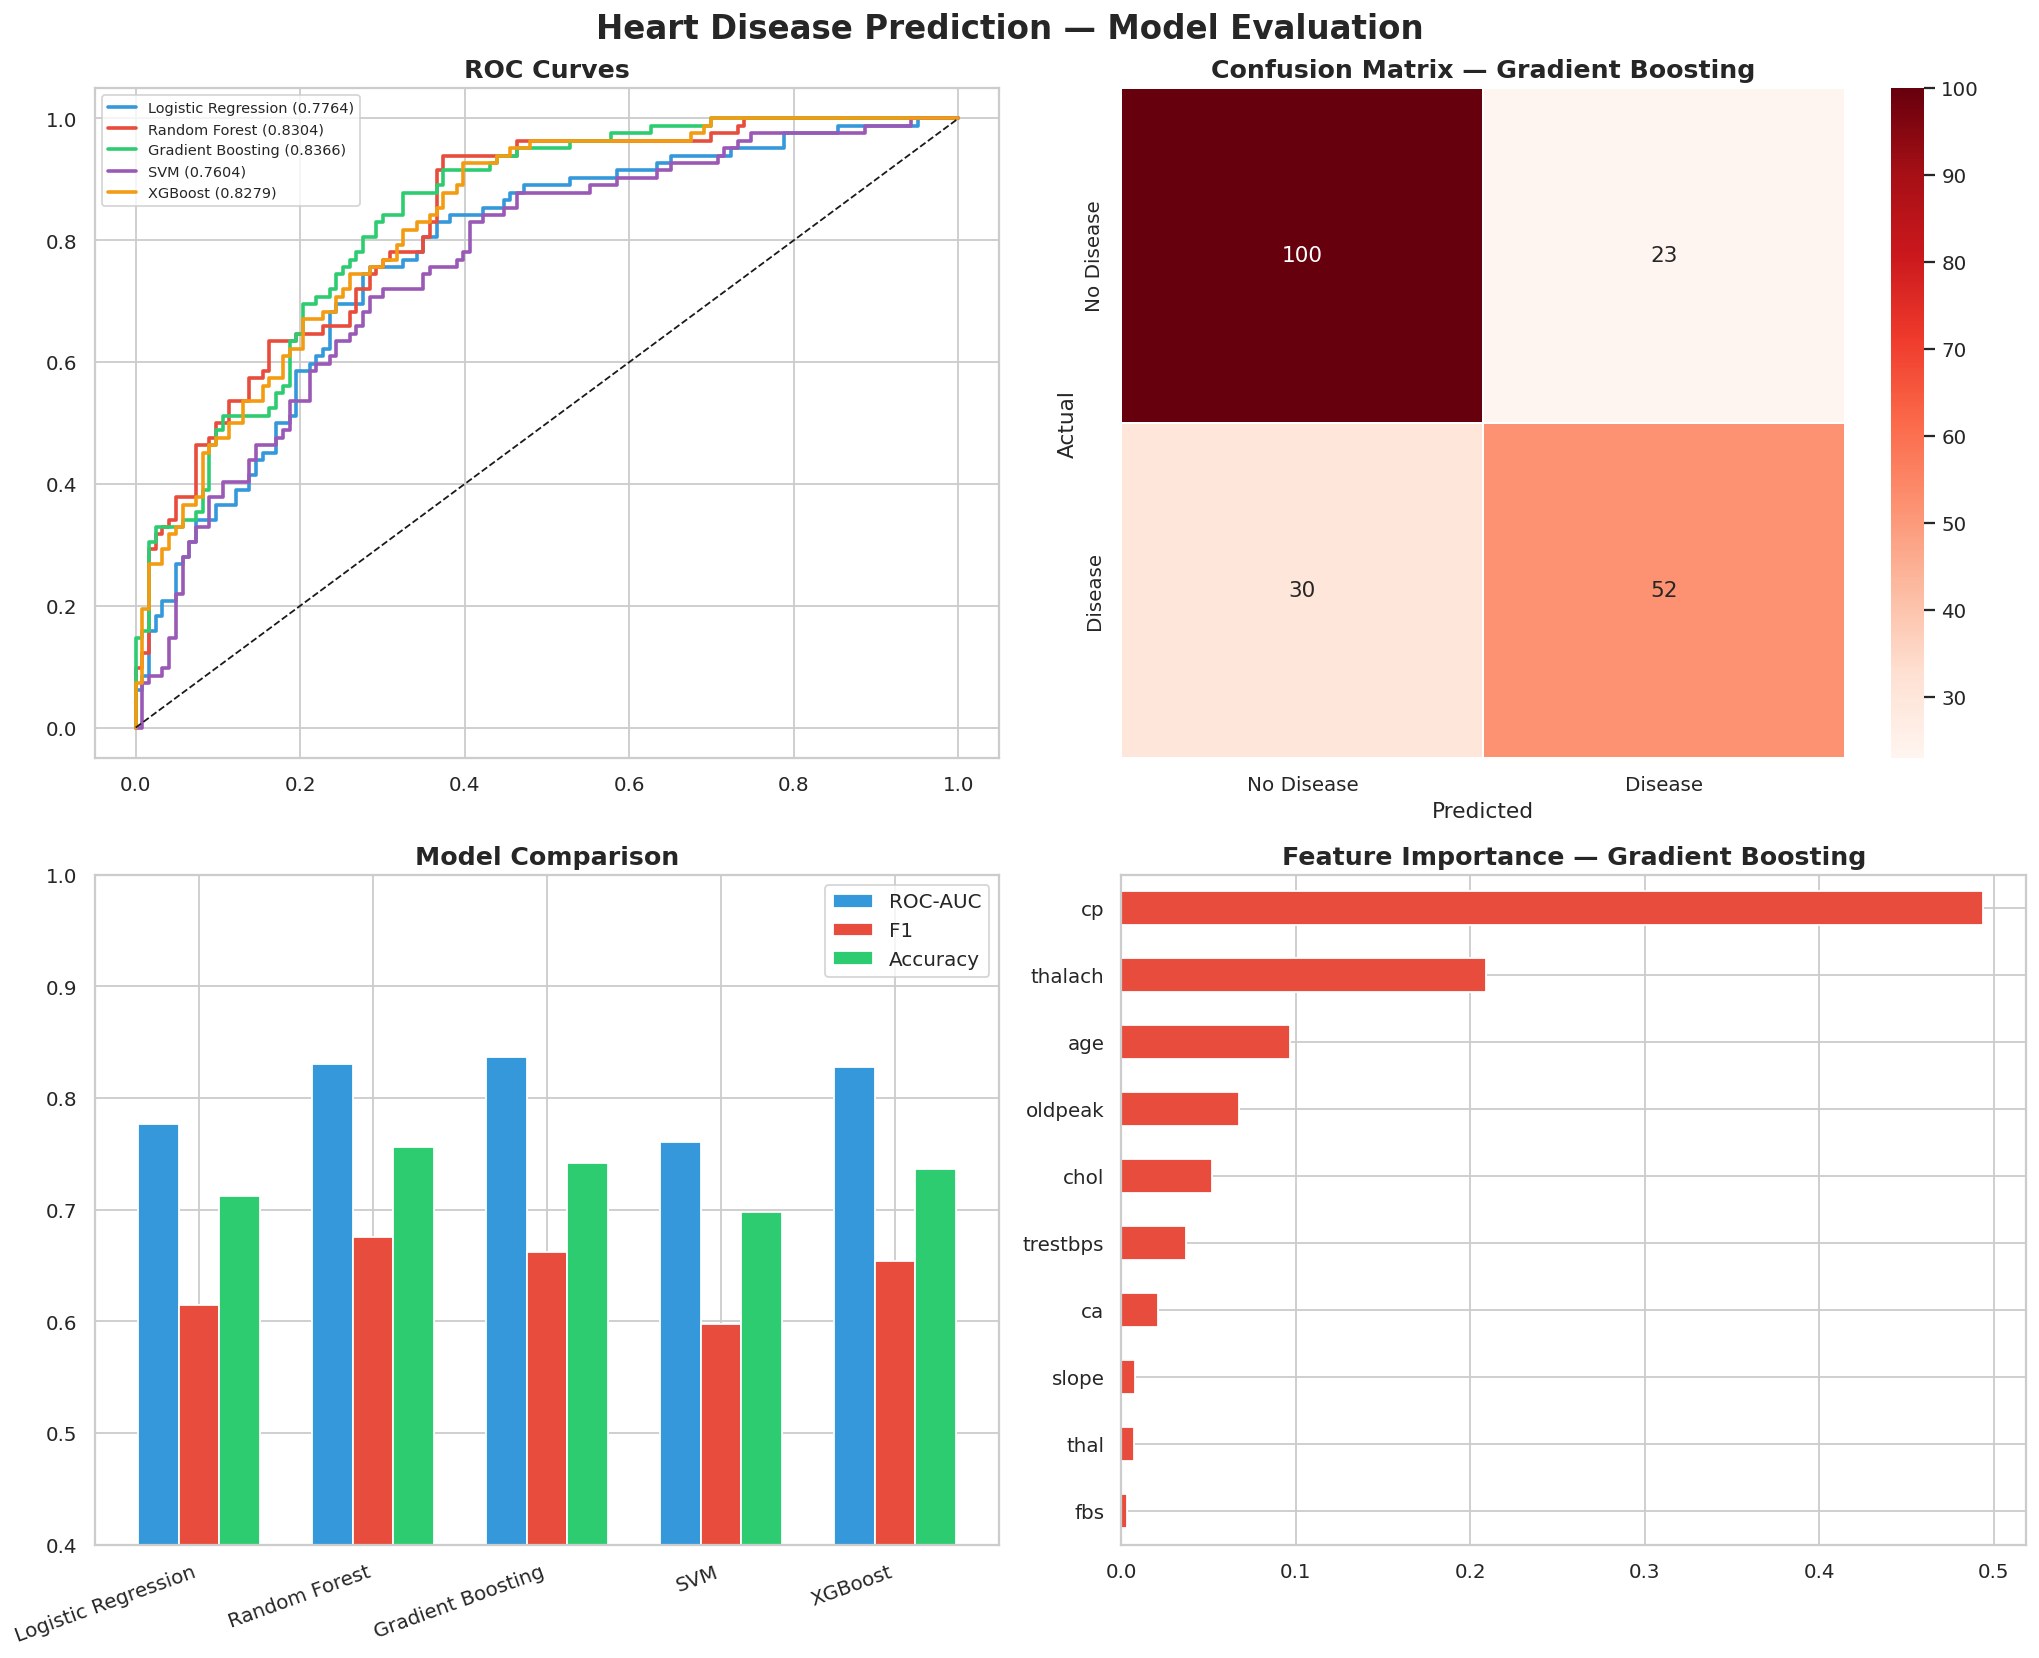

Saved → outputs/model_evaluation.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Heart Disease Prediction — Model Evaluation', fontsize=18, fontweight='bold')
COLORS = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12']

# ROC
for (nm, r), c in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0,0].plot(fpr, tpr, color=c, lw=2, label=f'{nm} ({r["roc_auc"]:.4f})')
axes[0,0].plot([0,1],[0,1],'k--',lw=1)
axes[0,0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0,0].legend(fontsize=8)

# Confusion Matrix
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0,1],
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'], linewidths=1)
axes[0,1].set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Actual'); axes[0,1].set_xlabel('Predicted')

# Model Comparison
metrics_compare = pd.DataFrame({k: {'ROC-AUC': v['roc_auc'], 'F1': v['f1'], 'Accuracy': v['accuracy']}
                                  for k, v in results.items()}).T
metrics_compare.plot(kind='bar', ax=axes[1,0], color=['#3498db','#e74c3c','#2ecc71'],
                     edgecolor='white', width=0.7)
axes[1,0].set_title('Model Comparison', fontsize=14, fontweight='bold')
axes[1,0].set_ylim(0.4, 1.0); axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=20, ha='right')

# Feature Importance
best_model = results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).nlargest(10)
    fi[::-1].plot(kind='barh', ax=axes[1,1], color='#e74c3c', edgecolor='white')
    axes[1,1].set_title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
else:
    axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('outputs/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/model_evaluation.png')

## 7️⃣ Classification Report

In [7]:
print(f'\n{"="*60}')
print(f'  BEST MODEL: {best_name}')
print(f'{"="*60}')
r = results[best_name]
print(f'  Accuracy  : {r["accuracy"]:.4f}')
print(f'  Precision : {r["precision"]:.4f}')
print(f'  Recall    : {r["recall"]:.4f}')
print(f'  F1-Score  : {r["f1"]:.4f}')
print(f'  ROC-AUC   : {r["roc_auc"]:.4f}')
print(f'\nFull Classification Report:')
print(classification_report(y_test, r['y_pred'], target_names=['No Disease','Heart Disease']))


  BEST MODEL: Gradient Boosting
  Accuracy  : 0.7415
  Precision : 0.6933
  Recall    : 0.6341
  F1-Score  : 0.6624
  ROC-AUC   : 0.8366

Full Classification Report:
               precision    recall  f1-score   support

   No Disease       0.77      0.81      0.79       123
Heart Disease       0.69      0.63      0.66        82

     accuracy                           0.74       205
    macro avg       0.73      0.72      0.73       205
 weighted avg       0.74      0.74      0.74       205



## 8️⃣ Export Best Model

In [8]:
joblib.dump(results[best_name]['model'], 'models/disease_model.pkl')
joblib.dump(scaler,                        'models/scaler.pkl')
joblib.dump(list(X.columns),               'models/feature_names.pkl')

print('✅ disease_model.pkl  → models/')
print('✅ scaler.pkl          → models/')
print('✅ feature_names.pkl   → models/')
print(f'\n🎉 Task 4 Complete! Best: {best_name} | ROC-AUC: {results[best_name]["roc_auc"]:.4f}')

✅ disease_model.pkl  → models/
✅ scaler.pkl          → models/
✅ feature_names.pkl   → models/

🎉 Task 4 Complete! Best: Gradient Boosting | ROC-AUC: 0.8366
